# GWTC-4 mass-redshift inference
#### Code: [gppop](https://github.com/AnaryaRay1/gppop/tree/main)

#### Contents 

- [Preamble](#Preamble), need to run.
- [Prepare Input for GWTC-4](#Prepare-input-for-GWTC-4)
- [Run Inference](#Run-inference)
- [GP sanity checks](#GP-sanity-checks)



## Preamble

In [1]:
import numpy as np
import pandas as pd
import h5py
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator,LogLocator,NullFormatter)
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import glob
import yaml
from astropy.cosmology import Planck15,z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
import aesara.tensor as tt

In [3]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.sans-serif'] = ['Bitstream Vera Sans']
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

import seaborn as sns
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('colorblind')
colors=sns.color_palette('colorblind')
fs=80

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

In [5]:
import pymc as pm

In [6]:
import arviz as az

In [7]:
from gppop.core_m1m2z import Utils,Vt_Utils, Rates

In [8]:
from gppop.core_m1m2z import log_prob_spin, reweight_pinjection

In [9]:
mbins = np.logspace(np.log10(5), np.log10(200), 23)
zbins= np.array([0.01, 0.1,  0.25, 0.5,  0.75, 1.,   1.25, 1.5, 2.0])

In [10]:
utils = Utils(mbins,zbins)

## Prepare input for GWTC-4
Needs data on CIT to run, can skip directly to [this cell](#Plot-results)

In [11]:
Zs = np.linspace(0.,10,1000)
DLs = Planck15.luminosity_distance(Zs).value
z_interp = interp1d(DLs,Zs)

In [12]:
import os

In [13]:
with open('../gwtc-4.yaml', "r") as stream:
    config = yaml.full_load(stream)

In [14]:
N=1e6
import tqdm
for filename in tqdm.tqdm(config['pe_summary_event_dict'].values()):
    
    with h5py.File(filename[1],'r') as hf:
        try:
            if len(filename[0])>0:
                posterior = hf[filename[0]]['posterior_samples'][()]
            else:
                posterior = hf['posterior_samples'][()]
        except KeyError:
            
            posterior = hf['posterior']
            
        m1 = posterior['mass_1_source']
        if N>len(m1):
            N=len(m1)
        
print(N)

N_samples = N
np.random.seed(2**31-78)




posterior_samples_o4 = np.zeros((len(config['pe_summary_event_dict'].keys()),N_samples,3))
for i,filename in enumerate(tqdm.tqdm(config['pe_summary_event_dict'].values())):
    
    testkey=False
    with h5py.File(filename[1],'r') as hf:
        try:
            if len(filename[0])>0:
                posterior = hf[filename[0]]['posterior_samples'][()]
            else:
                posterior = hf['posterior_samples'][()]
            this_N_samples = len(posterior)
        except KeyError:
            testkey=True
            posterior = hf['posterior']
            this_N_samples = len(posterior['mass_1_source'])
        indices = np.random.choice(this_N_samples,size=N_samples,replace=False)
        
        if not testkey:
            z = posterior['redshift'][indices]
            m1 = posterior['mass_1_source'][indices]
            m2 = posterior['mass_2_source'][indices]
        else:
            z = posterior['redshift'][()][indices]
            m1 = posterior['mass_1_source'][()][indices]
            m2 = posterior['mass_2_source'][()][indices]
        posterior_samples_o4[i,:,:] = np.array([m1,m2,z]).T

        
posterior_samples_all = posterior_samples_o4.copy()
posterior_samples_o4 = [ ]


100%|██████████| 153/153 [00:09<00:00, 16.43it/s]


1993


100%|██████████| 153/153 [00:09<00:00, 16.38it/s]


In [15]:
posterior_samples_all.shape


(153, 1993, 3)

In [16]:
log_bin_centers=utils.generate_log_bin_centers()
tril_deltaLogbin = utils.arraynd_to_tril(utils.deltaLogbin())

In [17]:
weights = [ ]
wt_means = [ ]
wt_sigmas = [ ]
for i,posterior_samples_this_event in enumerate(posterior_samples_all):
    weight_set = utils.compute_weights(posterior_samples_this_event,O4_prior = True)
    weights.append(utils.arraynd_to_tril(weight_set[0]))
    wt_means.append(utils.arraynd_to_tril(weight_set[1]))
    wt_sigmas.append(utils.arraynd_to_tril(weight_set[2]))
    #weights.append(compute_weights_with_q(utils, posterior_samples_this_event,z_prior=spin_priors[i]))
    if i%10==0:
        print(i)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150


In [18]:
weights = np.array(weights)
wt_means = np.array(wt_means)
wt_sigmas = np.array(wt_sigmas)

In [19]:
weights_norm = np.sum(weights, axis = 1)
weights_cut = (weights.T / weights_norm).T
weights_cut.shape

(153, 2024)

In [20]:
os.chdir('data/')

In [21]:
np.savetxt('wt_means_GWTC4_newbins3_m1m2z.txt',wt_means)
np.savetxt('wt_sigmas_GWTC4_newbins3_m1m2z.txt',wt_sigmas)

In [22]:
wts_sum = np.sum(weights_cut,axis=0)

In [23]:
w= utils.construct_1dtond_matrix(len(mbins)-1,wts_sum,nbins_z=len(zbins)-1)

(22, 22, 8)


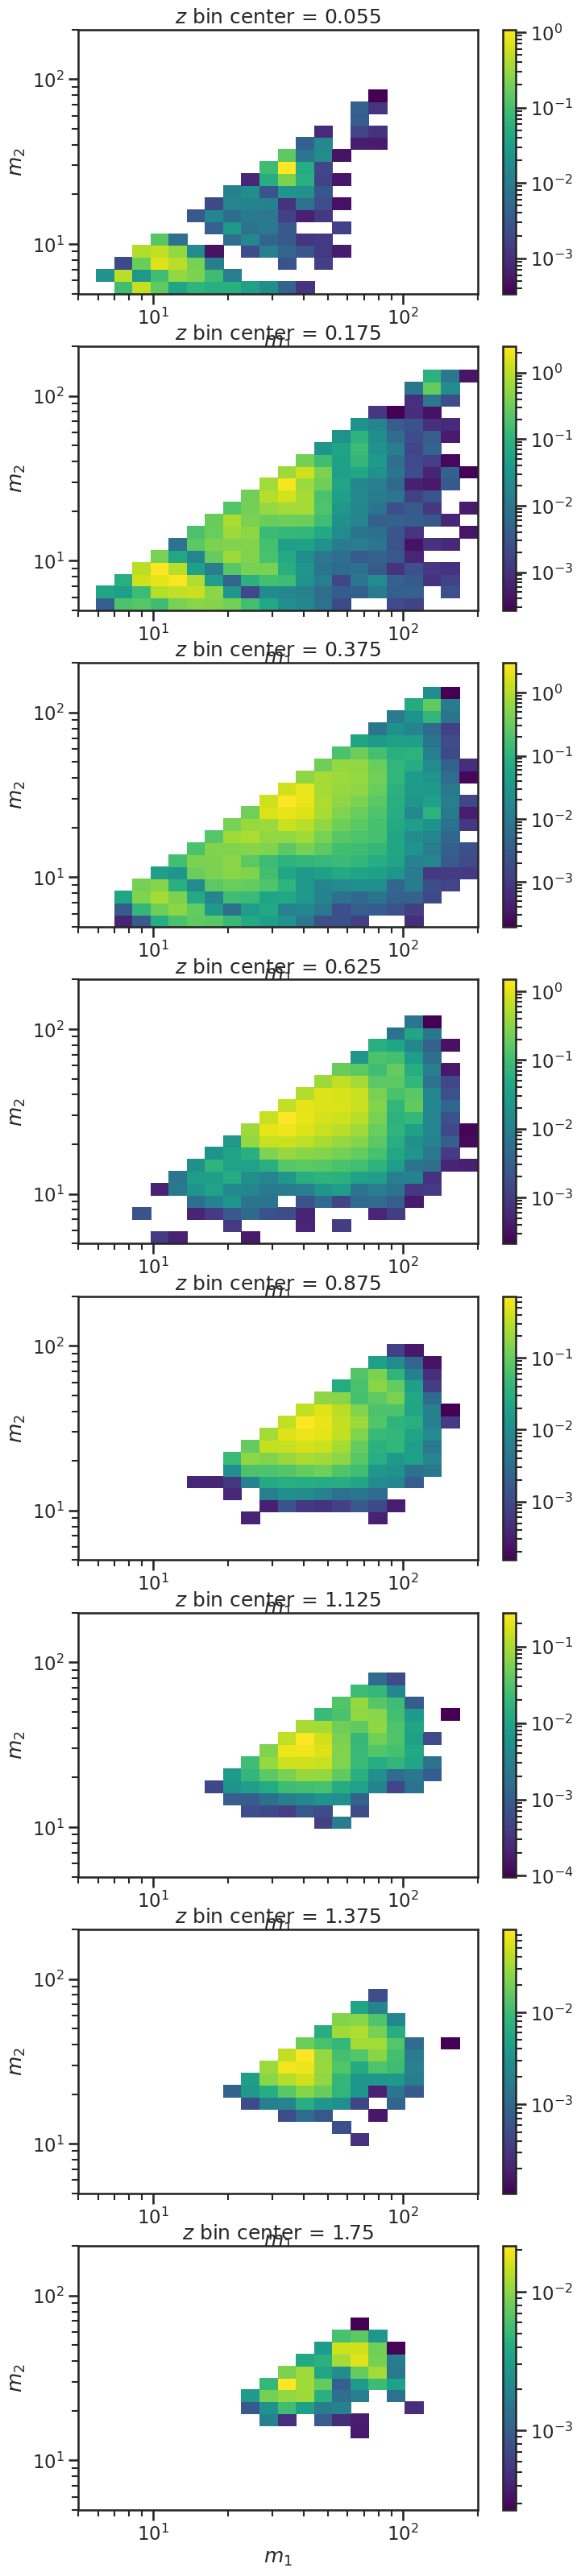

In [25]:
fig,axes = plt.subplots(len(zbins)-1,figsize=(8,40))
wts_sum = np.sum(weights,axis=0)
w= utils.construct_1dtond_matrix(len(mbins)-1,wts_sum,nbins_z=len(zbins)-1)
#w = wts_sum
print(w.shape)
for i in range(len(zbins)-1):
        ax = axes[i]
        ax.set_title(r'$z$ bin center = '+str(0.5*(zbins[i+1]+zbins[i])))
        matrix1 = w[:,:,i]
        if(matrix1.min()==matrix1.max()):
            continue

        pc = ax.pcolor(mbins,mbins,matrix1.T,norm=LogNorm(vmin=matrix1[matrix1!=0].min(),vmax=matrix1.max()),cmap='viridis')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$m_1$')
        ax.set_ylabel(r'$m_2$')
        plt.colorbar(pc, ax = ax)
    #fig.colorbar()
plt.show()
#plt.savefig('weights_z_bin_center_plots_case_9mdo.pdf')

In [28]:
vt_utils = Vt_Utils(mbins,zbins)

In [29]:
inj_dataset = {}
with h5py.File(config['injection_file'],'r') as hf:
    #print(hf['events'][()].dtype)
    
    m2 = hf["events"][()]["mass2_source"]
    inj_dataset['analysis_time_s'] = hf.attrs['total_analysis_time'] # years
    inj_dataset['total_generated'] = hf.attrs['total_generated']
    mix_weights = hf['events'][()]['weights']
    for param,key in config['injection_keys'].items():
            inj_dataset[param] = hf['events'][()][key]

thresh = config['threshold']
thresh_keys = config['threshold_keys']
for key in thresh_keys:
    if 'o1o2' in key:
        continue
    inj_dataset[key] = 1./inj_dataset[key] 
inj_dataset["mixture_weight"] = mix_weights
inj_dataset["sampling_pdf"] = np.exp(inj_dataset["sampling_pdf"])

In [30]:
vt_means,vt_sigmas = vt_utils.compute_VTs(inj_dataset,thresh,key = thresh_keys )

In [31]:
np.savetxt('vt_means_GWTC4_newbins3_m1m2z.txt',vt_means)
np.savetxt('vt_sigmas_GWTC4_newbins3_m1m2z.txt',vt_sigmas)

In [33]:
vts_nd = utils.construct_1dtond_matrix(len(mbins)-1,vt_means,nbins_z=len(zbins)-1)

In [34]:
wbyv = wts_sum/(vt_means + 1e-30)

In [35]:
nbins_m = len(mbins)-1
nbins_m = int(0.5*nbins_m*(nbins_m+1))
nbins_z = len(zbins)-1

In [36]:
args = np.where(wbyv > 1e20)[0]
args

array([ 406,  424,  425,  426,  427,  445,  446,  464,  465,  466,  643,
        660,  661,  677,  679,  680,  698,  699,  719,  767,  769,  774,
        782,  838,  865,  882,  898,  914,  915,  933,  934, 1136, 1151,
       1152, 1190, 1360, 1374, 1390, 1443, 1463, 1590, 1628, 1642, 1660,
       1678, 1697, 1897, 1898, 1933, 1950])

In [37]:
def interpolate_vts(log_bin_centers,tril_deltaLogbin,tril_vts,arg=None):
        '''
        Function for interpolating VTs over bins that have no injections
        using a GP regressor.
        
        Parameters
        ----------
        
        tril_vts  :: numpy.ndarray
                     1d array containing VT meands or stds to be interpolated.
        
        arg       :: numpy.ndarray
                     1d array containing bin indices at which interpolated
                     VTs need to be calculated.
                     
        Returns
        -------
        
        new_vts  : numpy.ndarray
                   interpolated VTs.
        '''
        if(all(tril_vts>0) or arg is None):
            return tril_vts
        
        vts = tril_vts/tril_deltaLogbin
        X =log_bin_centers[vts!=0]
        y = np.log((vts)[vts!=0])
        kernel = RBF(length_scale=0.3,length_scale_bounds=[0.08,2])
        gp = GaussianProcessRegressor(kernel=kernel,n_restarts_optimizer=5).fit(X,y)
        y_pred = gp.predict(log_bin_centers[arg.astype(int)])
        vt_pred = np.exp(y_pred)
        new_vts = vts.copy()
        new_vts[arg.astype(int)] = vt_pred
        print(vt_pred)
        return new_vts*tril_deltaLogbin

In [38]:
interp_vts = interpolate_vts(log_bin_centers,tril_deltaLogbin,vt_means,arg=args)

[3.42701131e-01 7.37152819e-01 6.05899334e-01 2.42241749e+00
 9.47157920e+00 1.85664054e+00 2.91880759e+00 1.04485203e+00
 1.49145091e+00 1.10958866e+01 5.09367597e+00 1.34719820e+00
 4.39839275e+00 1.93014517e+00 3.40384283e+00 5.75037660e+00
 1.51883116e+00 8.53238487e-01 2.30352298e-01 1.09857541e-02
 4.93656735e-01 3.07639577e-01 5.38018779e-02 3.24743120e-02
 3.13307641e-01 7.97350313e-01 5.85386109e-01 8.31577205e-01
 3.31522233e-01 4.40174425e-01 1.09128791e-01 3.35872004e-02
 7.61283475e-01 2.86903205e-01 6.95556234e-01 6.70973486e-01
 5.21810383e-01 2.04246332e-01 1.29795603e-01 1.06816747e-01
 2.98243782e-02 2.73694408e-01 9.31672871e-01 4.39646985e-01
 6.76767973e-01 2.88205196e+00 5.11524707e-01 1.39851691e-01
 2.09935060e-01 2.73119343e-01]


In [39]:
vt_means[args], interp_vts[args], wbyv[args]

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([1.44527458e-03, 3.10879693e-03, 2.55526119e-03, 1.02160690e-02,
        3.99445212e-02, 7.83001607e-03, 1.23094966e-02, 4.40645780e-03,
        6.28990067e-03, 4.67947179e-02, 3.58026266e-02, 9.46923879e-03,
        3.09155930e-02, 1.35666790e-02, 2.39250620e-02, 4.04184693e-02,
        1.06756192e-02, 5.99727565e-03, 1.61910913e-03, 7.72170928e-05,
        3.46983354e-03, 2.16234895e-03, 3.78164719e-04, 2.28256699e-04,
        2.20218885e-03, 5.60444670e-03, 4.11458451e-03, 5.84502200e-03,
        2.33021629e-03, 3.09391501e-03, 7.67048667e-04, 2.36079012e-04,
        5.35093871e-03, 2.01659634e-03, 4.88895254e-03, 4.71616437e-03,
        3.66772099e-03, 1.43561451e-03, 9.12312353e-04, 7.50797680e-04,
        2.09630742e-04, 1.92375383e-03, 6.54857828e-03

In [40]:
ivts_nd = utils.construct_1dtond_matrix(len(mbins)-1,interp_vts,nbins_z=len(zbins)-1)
wbyvfinal = w/(ivts_nd + 1e-30)
np.where(wbyvfinal > 1e10)

(array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))

In [42]:
np.savetxt('weights_GWTC4_IFAR1_newbins3_m1m2z.txt',weights_cut)

In [41]:
np.savetxt('vts_GWTC4_IFAR1_newbins3_m1m2z.txt',interp_vts/tril_deltaLogbin)

In [43]:
np.savetxt('mbins_m1m2z.txt',mbins)
np.savetxt('zbins_m1m2z.txt',zbins)

In [44]:
dist_array = np.zeros(int(nbins_m*(nbins_m+1)/2))

zbin_centers = log_bin_centers[0::nbins_m,2]
logm_bin_centers = log_bin_centers[:nbins_m,:2]
k=0
for i in range(len(logm_bin_centers)):
    for j in range(i+1):
        dist_array[k] = np.linalg.norm(logm_bin_centers[i]-logm_bin_centers[j])
        k+=1

scale_min = np.log(np.min(dist_array[dist_array!=0.]))
scale_max = np.log(np.max(dist_array))
scale_mean_m = 0.5*(scale_min + scale_max) # chosen to give coverage over the bin-grid
scale_sd_m = (scale_max - scale_min)/4 # fix 3-sigma difference to the sd of the length scale dist

dist_array = np.zeros(int(nbins_z*(nbins_z+1)/2))
k=0
for i in range(len(zbin_centers)):
    for j in range(i+1):
        dist_array[k] = np.linalg.norm(zbin_centers[i]-zbin_centers[j])
        k+=1

scale_min = np.log(np.min(dist_array[dist_array!=0.]))
scale_max = np.log(np.max(dist_array))
scale_mean_z = 0.5*(scale_min + scale_max) # chosen to give coverage over the bin-grid
scale_sd_z = (scale_max - scale_min)/4 # fix 3-sigma difference to the sd of the length scale dist
print(scale_mean_m,scale_sd_m,scale_mean_z,scale_sd_z)

-0.09017169839338424 0.8477740070008504 -0.7962903976838387 0.6619865692581262


In [45]:
np.savetxt('gp_inputs_newbins3_m1m2z.txt',np.array([scale_mean_m,scale_sd_m, scale_mean_z,scale_sd_z]))